<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [80]:
df = pd.read_csv('titanic_data.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Feature Engineering Starter

In [81]:
# Drop unnecessary column which has no significance to target column

df2 = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

df2

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [82]:
# Feature columns

X = df2.drop(['Survived'], axis = 1)

X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S
887,first,female,19.0,0,0,30.0000,B42,S
888,third,female,NaN,1,2,23.4500,NaN,S
889,first,male,26.0,0,0,30.0000,C148,C


In [83]:
# Target Column

y = df2['Survived']

y

,Survived
0,no
1,yes
2,yes
3,yes
4,no
...,...
886,no
887,yes
888,no
889,yes


# Train_Test Split Code


In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [85]:
X_train
display(y_train)

,Survived
331,no
733,no
382,no
704,no
813,no
...,...
106,yes
270,no
860,no
435,yes


In [86]:
X_test
display(y_test)

,Survived
709,yes
439,no
840,no
720,yes
39,yes
...,...
433,no
773,no
25,yes
84,yes


# Handling Missing Values


# Numerical Missing value Imputation using Pandas

In [87]:
X_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,140
SibSp,0
Parch,0
Fare,0
Cabin,553
Embarked,2


In [88]:
X_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,37
SibSp,0
Parch,0
Fare,0
Cabin,134
Embarked,0


In [89]:
# Impute using mean

age_mean = X_train['Age'].mean()

X_train['age_mean_imputer'] = X_train['Age'].fillna(age_mean)

X_test['age_mean_imputer'] = X_test['Age'].fillna(age_mean)

X_train
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputer
709,third,male,NaN,1,1,15.2458,NaN,C,29.498846
439,second,male,31.0,0,0,10.5000,NaN,S,31.000000
840,third,male,20.0,0,0,7.9250,NaN,S,20.000000
720,second,female,6.0,0,1,33.0000,NaN,S,6.000000
39,third,female,14.0,1,0,11.2417,NaN,C,14.000000
...,...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S,17.000000
773,third,male,NaN,0,0,7.2250,NaN,C,29.498846
25,third,female,38.0,1,5,31.3875,NaN,S,38.000000
84,second,female,17.0,0,0,10.5000,NaN,S,17.000000


In [90]:
# Impute using median

age_median = X_train['Age'].median()

X_train['age_median_imputer'] = X_train['Age'].fillna(age_median)

X_test['age_median_imputer'] = X_test['Age'].fillna(age_median)

X_train
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputer,age_median_imputer
709,third,male,NaN,1,1,15.2458,NaN,C,29.498846,28.0
439,second,male,31.0,0,0,10.5000,NaN,S,31.000000,31.0
840,third,male,20.0,0,0,7.9250,NaN,S,20.000000,20.0
720,second,female,6.0,0,1,33.0000,NaN,S,6.000000,6.0
39,third,female,14.0,1,0,11.2417,NaN,C,14.000000,14.0
...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S,17.000000,17.0
773,third,male,NaN,0,0,7.2250,NaN,C,29.498846,28.0
25,third,female,38.0,1,5,31.3875,NaN,S,38.000000,38.0
84,second,female,17.0,0,0,10.5000,NaN,S,17.000000,17.0


<Axes: xlabel='age_mean_imputer', ylabel='Density'>

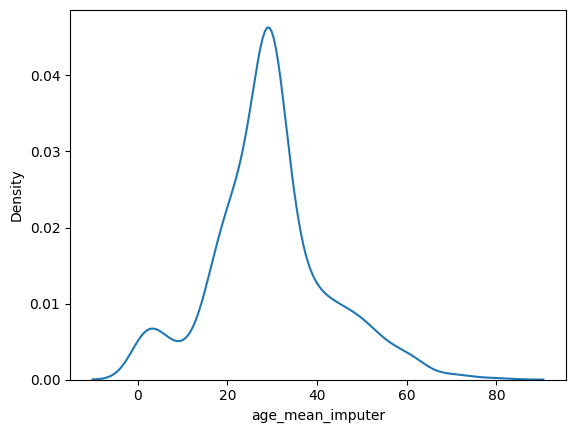

In [91]:
sns.kdeplot(data = X_train, x = 'age_mean_imputer')

<Axes: xlabel='age_median_imputer', ylabel='Density'>

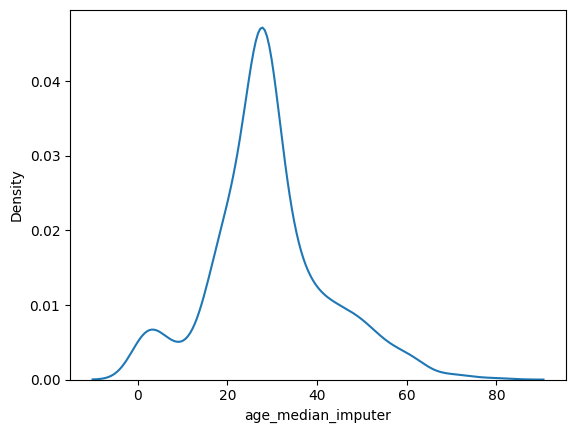

In [92]:
sns.kdeplot(data = X_train, x = 'age_median_imputer')

# Numerical Missing Values Imputation using Simple Imputer

In [93]:
# mean basis

age_imputer = SimpleImputer(missing_values = np.nan, strategy = 'mean')

age_imputer.fit(X_train[['Age']])

# convert a 2D data/list into 1D data/list using ravel()
X_train['Age'] = age_imputer.transform(X_train[['Age']]).ravel()

In [94]:
X_train.isnull().sum()

# X_train.drop(['age_mean_imputer', 'age_median_imputer'], axis = 1, inplace = True)

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputer,age_median_imputer
331,first,male,45.500000,0,0,28.5000,C124,S,45.500000,45.5
733,second,male,23.000000,0,0,13.0000,NaN,S,23.000000,23.0
382,third,male,32.000000,0,0,7.9250,NaN,S,32.000000,32.0
704,third,male,26.000000,1,0,7.8542,NaN,S,26.000000,26.0
813,third,female,6.000000,4,2,31.2750,NaN,S,6.000000,6.0
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,NaN,S,21.000000,21.0
270,first,male,29.498846,0,0,31.0000,NaN,S,29.498846,28.0
860,third,male,41.000000,2,0,14.1083,NaN,S,41.000000,41.0
435,first,female,14.000000,1,2,120.0000,B96 B98,S,14.000000,14.0


In [95]:
X_test['Age'] = age_imputer.transform(X_test[['Age']])

X_test.isnull().sum()

# X_test.drop(['age_mean_imputer', 'age_median_imputer'], axis = 1, inplace = True)

X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputer,age_median_imputer
709,third,male,29.498846,1,1,15.2458,NaN,C,29.498846,28.0
439,second,male,31.000000,0,0,10.5000,NaN,S,31.000000,31.0
840,third,male,20.000000,0,0,7.9250,NaN,S,20.000000,20.0
720,second,female,6.000000,0,1,33.0000,NaN,S,6.000000,6.0
39,third,female,14.000000,1,0,11.2417,NaN,C,14.000000,14.0
...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,NaN,S,17.000000,17.0
773,third,male,29.498846,0,0,7.2250,NaN,C,29.498846,28.0
25,third,female,38.000000,1,5,31.3875,NaN,S,38.000000,38.0
84,second,female,17.000000,0,0,10.5000,NaN,S,17.000000,17.0


# Categorical Value Imputation with Mode Value


In [96]:
embarked_imputer = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')

embarked_imputer.fit(X_train[['Embarked']])

# convert a 2D data/list into 1D data/list using ravel()
X_train['Embarked'] = embarked_imputer.transform(X_train[['Embarked']]).ravel()

X_test['Embarked'] = embarked_imputer.transform(X_test[['Embarked']]).ravel()

In [97]:
X_train.isnull().sum()
X_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,134
Embarked,0
age_mean_imputer,0
age_median_imputer,0


# Categorical Value Imputation with Missing string and Indicator

<Axes: xlabel='Cabin', ylabel='count'>

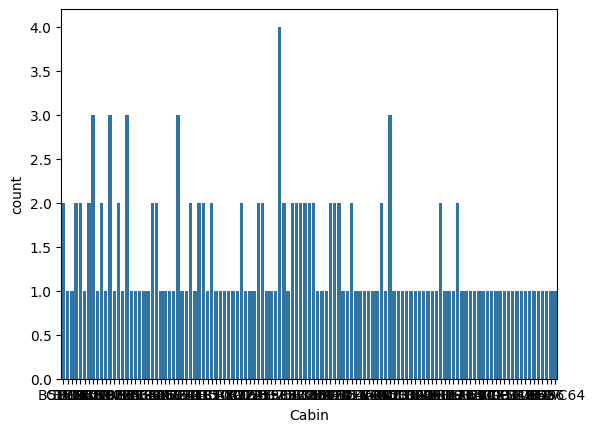

In [98]:
sns.countplot(data = X_train, x = X_train['Cabin'])

In [99]:
cabin_imputer = SimpleImputer(missing_values = np.nan, strategy = 'constant', fill_value = 'Missing', add_indicator = True)

cabin_imputer.fit(X_train[['Cabin']])

X_train[['Cabin', 'cabin_missing_indicator']] = cabin_imputer.transform(X_train[['Cabin']])

X_test[['Cabin', 'cabin_missing_indicator']] = cabin_imputer.transform(X_test[['Cabin']])

In [100]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputer,age_median_imputer,cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,45.500000,45.5,False
733,second,male,23.000000,0,0,13.0000,Missing,S,23.000000,23.0,True
382,third,male,32.000000,0,0,7.9250,Missing,S,32.000000,32.0,True
704,third,male,26.000000,1,0,7.8542,Missing,S,26.000000,26.0,True
813,third,female,6.000000,4,2,31.2750,Missing,S,6.000000,6.0,True
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,21.000000,21.0,True
270,first,male,29.498846,0,0,31.0000,Missing,S,29.498846,28.0,True
860,third,male,41.000000,2,0,14.1083,Missing,S,41.000000,41.0,True
435,first,female,14.000000,1,2,120.0000,B96 B98,S,14.000000,14.0,False


In [101]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputer,age_median_imputer,cabin_missing_indicator
709,third,male,29.498846,1,1,15.2458,Missing,C,29.498846,28.0,True
439,second,male,31.000000,0,0,10.5000,Missing,S,31.000000,31.0,True
840,third,male,20.000000,0,0,7.9250,Missing,S,20.000000,20.0,True
720,second,female,6.000000,0,1,33.0000,Missing,S,6.000000,6.0,True
39,third,female,14.000000,1,0,11.2417,Missing,C,14.000000,14.0,True
...,...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,17.000000,17.0,True
773,third,male,29.498846,0,0,7.2250,Missing,C,29.498846,28.0,True
25,third,female,38.000000,1,5,31.3875,Missing,S,38.000000,38.0,True
84,second,female,17.000000,0,0,10.5000,Missing,S,17.000000,17.0,True


In [102]:
X_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
age_mean_imputer,0
age_median_imputer,0


In [103]:
X_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
age_mean_imputer,0
age_median_imputer,0
